# <span style="color:darkblue;">[LDATS2350] - DATA MINING</span>

### <span style="color:darkred;">Python13 - Naïve Bayes</span>

**Prof. Olivier Caelen**  

<br/>

**<span style="color:darkgreen;">Kenrick So</span>** (<span style="color:gray;">kenrick.so@uclouvain.be</span>)

---

## 🔹 **What is Naïve Bayes?**
Naïve Bayes is a **probabilistic classification algorithm** based on **Bayes' Theorem**. It is widely used for **text classification**, **spam detection**, **sentiment analysis**, and other applications where categorical data plays a crucial role.

### **🔢 Bayes' Theorem**
The Naïve Bayes classifier is based on **Bayes' Theorem**, which states:

\[
P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}
\]

where:
- \( P(A|B) \) is the **posterior probability** (the probability of class \( A \) given evidence \( B \))
- \( P(B|A) \) is the **likelihood** (the probability of evidence \( B \) given class \( A \))
- \( P(A) \) is the **prior probability** (the probability of class \( A \) before considering \( B \))
- \( P(B) \) is the **marginal probability** (the probability of evidence \( B \) occurring)

---

## 🔹 **Why "Naïve"?**
The algorithm is called **"naïve"** because it **assumes** that all features are **independent** given the class label. This assumption **simplifies computation** and works well in many real-world scenarios, despite often being unrealistic.

---

## 🔹 **Types of Naïve Bayes Classifiers**
Naïve Bayes has different variants depending on the data type:

1. **Gaussian Naïve Bayes (GNB)** 🟠  
   - Used for **continuous data** (assumes Gaussian distribution).
   - Example: **Predicting spam emails based on word frequency**.

2. **Multinomial Naïve Bayes (MNB)** 🟢  
   - Used for **discrete data** (word counts, frequency of events).
   - Example: **Text classification (Spam vs. Ham)**.

3. **Bernoulli Naïve Bayes (BNB)** 🔵  
   - Used for **binary feature vectors** (presence or absence of a word).
   - Example: **Sentiment Analysis (Positive/Negative review classification)**.

---

## 🔹 **Advantages of Naïve Bayes**
✅ **Fast & Scalable** – Works well with large datasets.  
✅ **Handles Missing Data** – Can still classify even if some features are missing.  
✅ **Performs Well with Text Data** – Commonly used for NLP tasks.  
✅ **Interpretable** – Provides a clear probabilistic explanation.  

🛑 **Limitations**  
🚧 **Feature Independence Assumption** – Often unrealistic in real-world data.  
🚧 **Zero Probability Issue** – If a category never appears in training, the probability becomes 0.  

---

## 🔹 **Naïve Bayes in Action**
📌 **Spam Detection** – Filtering spam emails.  
📌 **Sentiment Analysis** – Classifying reviews as positive or negative.  
📌 **Medical Diagnosis** – Predicting diseases based on symptoms.  

---

## 🎯 **Key Takeaways**
- **Naïve Bayes** is a simple yet powerful probabilistic classifier.
- **Based on Bayes' Theorem** with an **independence assumption**.
- **Works well for text classification and categorical data**.
- **Fast, interpretable, and effective** despite its simplicity.

# Data import

In [1]:
import pandas as pd
data = pd.read_csv('diabetes.csv')

In [2]:
X = data.iloc[:,0:-1]
column_names = list(X) 
y = data.iloc[:,-1] 

In [3]:
from sklearn.model_selection import train_test_split

#SPLIT DATA INTO TRAIN AND TEST SET
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size =0.30, #by default is 75%-25%
                                                    #shuffle is set True by default,
                                                    stratify=y,
                                                    random_state= 123) #fix random seed for replicability

print(X_train.shape)
print(X_test.shape)

(537, 8)
(231, 8)


# Model

## 📌 **Bayes Theorem in Naïve Bayes Classification**
Bayes' Theorem provides a way to update our beliefs based on new evidence. In the context of classification, it allows us to compute the **posterior probability** of a class given the observed features.

### **🔹 Bayes' Theorem Formula**

$p(y|\mathbf{x}) = \frac{p(\mathbf{x}|y)p(y)}{p(\mathbf{x})} = \frac{p(\mathbf{x}|y)p(y)}{\sum_{i=1}^H p(\mathbf{x}|y_i)p(y_i)}$

- $p(y|\mathbf{x})$ : Posterior probability of class \( y \) given the feature vector $\mathbf{x} .$
- $ p(\mathbf{x}|y) $: Likelihood – Probability of observing $\mathbf{x}$  given class  y .
- $ p(y) $: Prior probability of class $ y $ (before seeing the features).
- $ p(\mathbf{x}) $: Normalization factor (marginal probability of $ \mathbf{x}) .$

---

## 🔹 **Maximum A Posteriori (MAP) Hypothesis**
In classification, we want to predict the **most probable class** given the features. The **Maximum A Posteriori (MAP) hypothesis** selects the class with the highest posterior probability:


$y_{MAP} = \arg \max_{y \in H} P(y|\mathbf{x}) = \arg \max \frac{p(\mathbf{x}|y)p(y)}{\sum_{i=1}^H p(\mathbf{x}|y_i)p(y_i)}$


Since the denominator $ p(\mathbf{x}) $ is constant across all classes, we simplify it as:


$y_{MAP} = \arg \max_{y \in H} p(\mathbf{x}|y)p(y)$

This means that we classify a new sample by choosing the class that **maximizes the product of the likelihood and the prior probability**.

---

## 🔹 **Naïve Independence Assumption**
The **"naïve"** assumption in Naïve Bayes states that all features are **conditionally independent** given the class:


$P(\mathbf{x}|y) = P(x_1|y)P(x_2|y)...P(x_n|y)=\prod_{j=1}^n P(x_j|y)$

This simplifies computation significantly since we do not need to compute joint probabilities for multiple features.

---

## 🔹 **Handling Different Types of Attributes**
### **1️⃣ Categorical/Discrete Attributes**
For categorical features (e.g., words in text classification, colors, categories):


$P(x_j|y) = P(x_j = r_{jk} | y = v_n)$

Where $ P(x_j = r_{jk} | y = v_n) $ represents the **empirical frequency** of the observed class $v_n $.

📝 **Example:**  
If we are classifying emails as spam or not spam and we have the feature "contains the word FREE", we estimate:

$P(\text{"FREE"} | \text{Spam}) = \frac{\text{Count of "FREE" in spam emails}}{\text{Total spam emails}}$

---

### **2️⃣ Numerical (Continuous) Attributes**
For numerical features (e.g., age, income), we assume a **Gaussian (Normal) distribution**:


$P(x_j|y) \sim N(\mu_{jh}, \sigma_{jh}^2)$

That is, we model each feature $ x_j $ as following a **Normal distribution** with:
- Mean $ \mu_{jh} $ estimated from the training data.
- Variance $ \sigma_{jh}^2 $ estimated from the training data.

📝 **Example:**  
If we classify people as "High Income" or "Low Income" based on their age:

$P(\text{Age} | \text{High Income}) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x - \mu)^2}{2\sigma^2}}$

---

## 🎯 **Key Takeaways**
✅ **Bayes' Theorem** allows us to calculate class probabilities given the features.  
✅ **Naïve Bayes assumes feature independence**, making it computationally efficient.  
✅ **Categorical features use frequency-based probabilities**, while **numerical features assume a Gaussian distribution**.  
✅ **Despite the "naïve" assumption, Naïve Bayes performs well in many real-world applications**, especially in text classification.


<div style="border: 2px solid darkblue; padding: 10px; background-color: #89D9F5;">

### **📌 Exercise: Implement and Evaluate a Naïve Bayes Classifier**
In this exercise, you will **train, evaluate, and analyze** a Naïve Bayes model for classification.

#### **🚀 Steps to Follow:**
1. **Train a Naïve Bayes classifier** using the provided dataset.
2. **Make predictions** on both the training and test sets.
3. **Evaluate the model's performance** using:
   - F1-score for both training and test sets.
   - ROC curve and AUC score.

</div>

***RESULTS ON TEST SET***
F1-score (Test): 0.6666666666666666
***RESULTS ON TRAIN SET***
F1-score (Train): 0.6288951841359773


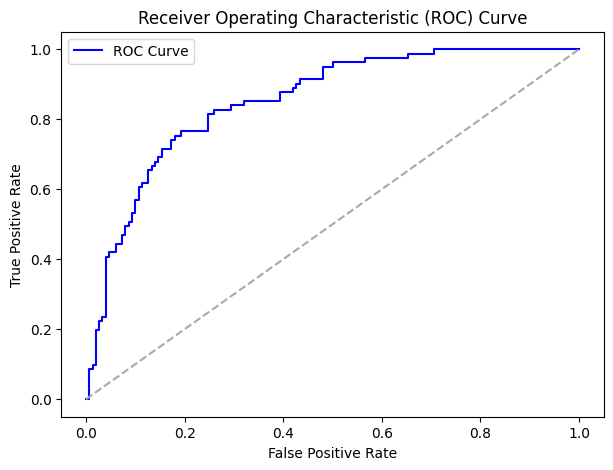

AUC Score: 0.85


In [4]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import f1_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Step 1: Define and train the Naïve Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# Step 2: Make predictions
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

# Step 3: Evaluate the model's performance
print('***RESULTS ON TEST SET***')
print("F1-score (Test):", f1_score(y_test, y_pred))

print('***RESULTS ON TRAIN SET***')
print("F1-score (Train):", f1_score(y_train, y_pred_train))

# Step 4: Compute and plot the ROC Curve
y_probs = model.predict_proba(X_test)[:,1]  # Get probability estimates for positive class
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label='ROC Curve', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='darkgray')  # Diagonal reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

# Step 5: Compute and print the AUC Score
auc = roc_auc_score(y_test, y_probs)
print('AUC Score: %.2f' % auc)